In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
import time

In [25]:
def load_and_filter():
    iris = datasets.load_iris()
    X = iris.data[:, 2:]
    y = iris.target
    mask = y != 0
    X = X[mask]
    y = y[mask]
    
    return X, y

In [26]:
class standardScaler:
    def __init__(self):
        self.mean = None
        self.std = None
        
    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std[self.std == 0] = 1
        return self

    def transform(self, X):
        return (X - self.mean) / self.std
    
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [ ]:
def train_test_split_scaled(X, y, train_ratio=0.7, random_state=42):
    np.random.seed(random_state)
    n_samples = X.shape[0]

    indices = np.random.permutation(n_samples)

    split_idx = int(train_ratio * n_samples)

    train_idx = indices[:split_idx]
    test_idx = indices[split_idx:]

    scaler = standardScaler()
    X_train = scaler.fit_transform(X[train_idx])
    X_test = scaler.transform( X[test_idx])

    return X_train, y[train_idx], X_test, y[test_idx]

In [28]:
def accuracy_score(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

In [29]:
def plot_decision_boundary(clf, X, y, title):
    plt.figure(figsize=(8, 6))
    
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', s=50)
    
    sv = clf.support_vectors_
    plt.scatter(sv[:, 0], sv[:, 1], s=150, linewidth=1.5, facecolors='none', edgecolors='k', label='Support Vectors')
    
    plt.xlabel('Petal Length')
    plt.ylabel('Petal Width')
    plt.title(title)
    plt.legend()
    plt.show()

In [ ]:
def run_experiment():
    C_values = [0.01, 0.1, 1, 10, 100]
    seeds = range(10)
    results = []

    X, y = load_and_filter()

    print(f"{'C':<6} | {'Train Acc':<10} | {'Test Acc':<10} | {'Time (ms)':<10} | {'n_Support Vectors'}")
    print("-" * 60)

    for C in C_values:
        train_accs = []
        test_accs = []
        times = []
        n_svs = []

        last_model = None
        last_X_train= None
        last_y_train = None

        for seed in seeds:

            X_train, y_train, X_test, y_test = train_test_split_scaled(X, y, train_ratio=0.7, random_state=seed)

            clf = SVC(kernel='linear', C=C)

            start_time = time.time()
            clf.fit(X_train, y_train)
            end_time = time.time()

            pred_train = clf.predict(X_train)
            pred_test = clf.predict(X_test)

            acc_train  = accuracy_score(y_train, pred_train)
            acc_test  = accuracy_score(y_test, pred_test)

            time_length = (end_time - start_time)*1000
            svs = len(clf.support_vectors_)

            train_accs.append(acc_train)
            test_accs.append(acc_test)
            times.append(time_length)
            n_svs.append(svs)

            last_model = clf
            last_X_train = X_train
            last_y_train = y_train

        avg_train_acc = np.mean(train_accs)
        avg_test_acc = np.mean(test_accs)
        avg_time = np.mean(times)
        avg_n_sv = np.mean(n_svs)

        results.append({
            'C' : C,
            'Train_acc' : avg_train_acc,
            'Test_acc' : avg_test_acc,
            'Time' : avg_time,
            'Support_Vectors' : avg_n_sv
        })

        print(f"{C:<6} | {avg_train_acc:.4f}     | {avg_test_acc:.4f}     | {avg_time:.4f}     | {avg_n_sv:.1f}")

        plot_title = f"SVM Decision Boundary (C={C})\nAvg SV Count: {avg_n_sv:.1f}"
        plot_decision_boundary(last_model, last_X_train, last_y_train, plot_title)

    return pd.DataFrame(results)

C      | Train Acc  | Test Acc   | Time (ms)  | n_Support Vectors
------------------------------------------------------------
0.01   | 0.9529     | 0.9167     | 0.7032     | 58.2


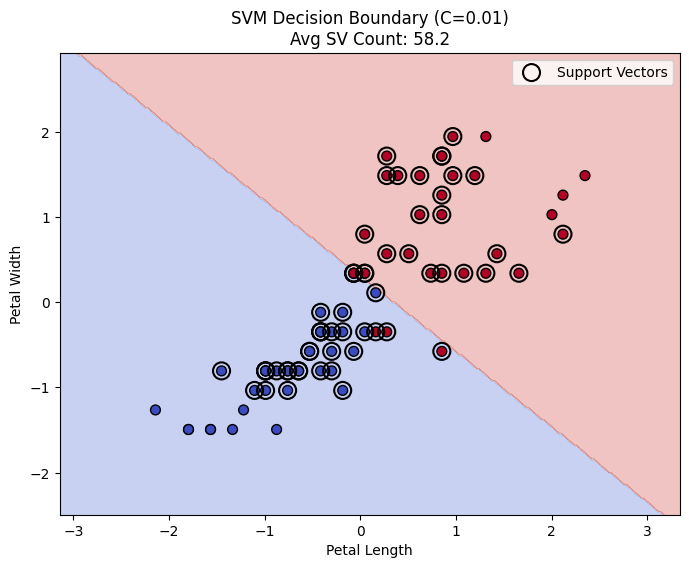

0.1    | 0.9514     | 0.9167     | 0.6369     | 27.3


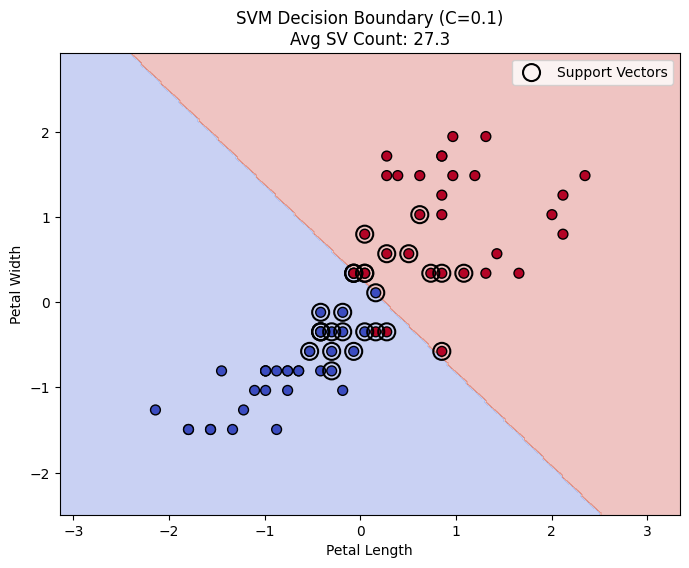

1      | 0.9543     | 0.9200     | 0.6023     | 13.3


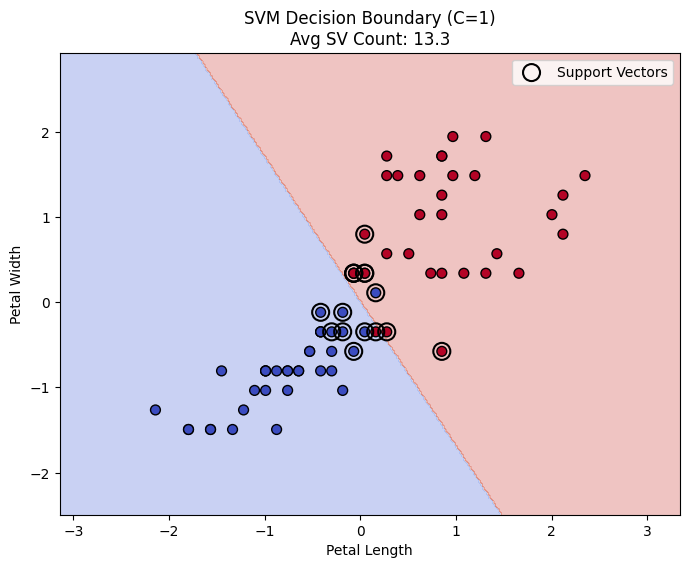

10     | 0.9557     | 0.9167     | 0.6017     | 9.1


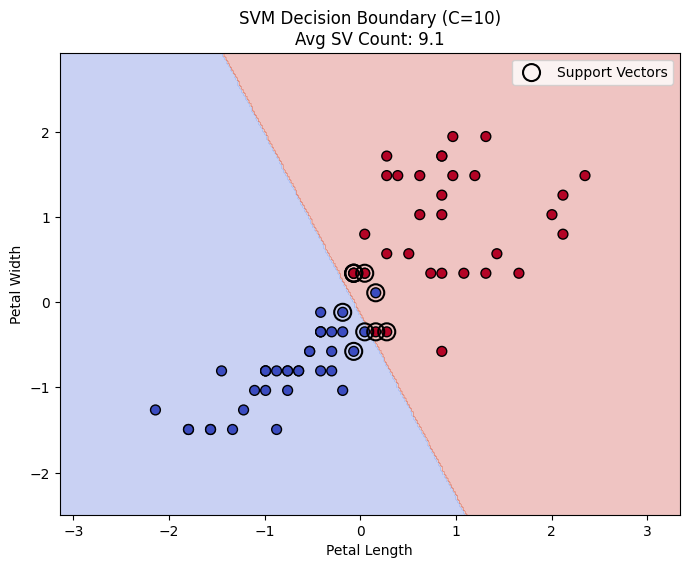

100    | 0.9543     | 0.9200     | 0.6048     | 8.1


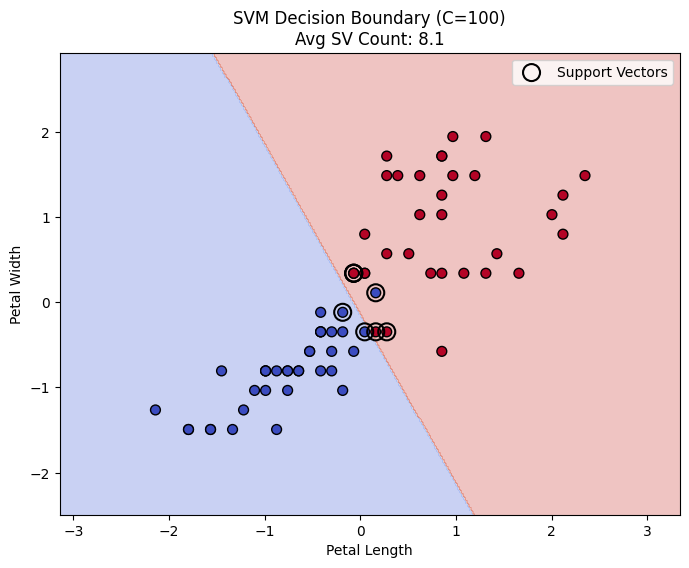

In [31]:
df_results = run_experiment()